# Лабораторная работа №7: Авторегресионная модель

### Капанадзе Давид

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

df = pd.read_csv('lab_03/data.csv', sep=';')
df.rename(columns={'date1': 'month', 'date2': 'year', 'x2': 'avg_daily_rate'}, inplace=True)
df.drop(columns=['x1', 'x3', 'x4'], inplace=True)
df['avg_daily_rate'] = df['avg_daily_rate'].apply(lambda x: '.'.join(x.split(',')))
df = df[df['avg_daily_rate'] != ' ']
df['avg_daily_rate'] = df['avg_daily_rate'].astype(float)
df['year'] = df['year'].astype(int)

def month2n(month: str):
    monthes = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
    ]

    return monthes.index(month) + 1


df['month_n'] = df['month'].apply(month2n)
df['timestamp'] = (df['year'] - 1994) * 12 + df['month_n']
df.head()

,month,year,avg_daily_rate,month_n,timestamp
0,January,1994,104.04,1,1
1,February,1994,102.74,2,2
2,March,1994,105.23,3,3
3,April,1994,113.63,4,4
4,May,1994,120.77,5,5


<Axes: >

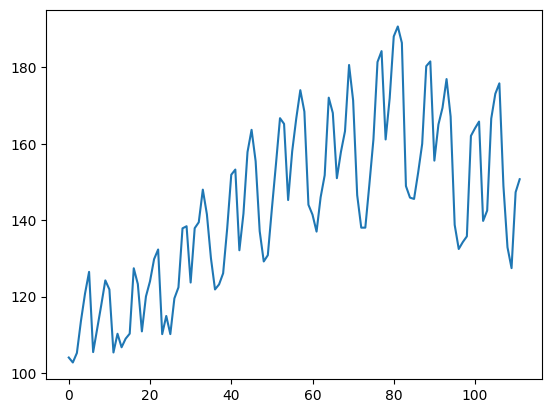

In [37]:
df['avg_daily_rate'].plot()

#### Имеется тренд -> перейдём к разностям

<Axes: >

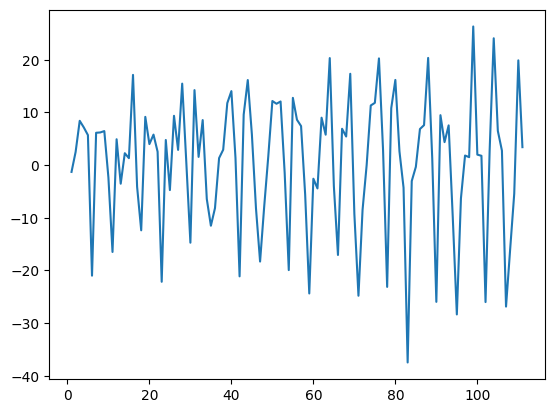

In [38]:
df['avg_daily_rate'] = df['avg_daily_rate'].diff()

df['avg_daily_rate'].plot()

#### Тренда нет, но дисперсия меняется - ряд не стационарный

----

### Модель авторегрессии

In [94]:
df_autoreg = df[['avg_daily_rate', 'timestamp']]

df_autoreg['lag1'] = df_autoreg['avg_daily_rate'].shift(1)
df_autoreg['lag2'] = df_autoreg['avg_daily_rate'].shift(2)
df_autoreg['lag3'] = df_autoreg['avg_daily_rate'].shift(3)
df_autoreg['lag4'] = df_autoreg['avg_daily_rate'].shift(4)
df_autoreg['lag5'] = df_autoreg['avg_daily_rate'].shift(5)
df_autoreg['lag6'] = df_autoreg['avg_daily_rate'].shift(6)
df_autoreg['lag7'] = df_autoreg['avg_daily_rate'].shift(7)
df_autoreg['lag8'] = df_autoreg['avg_daily_rate'].shift(8)
df_autoreg['lag9'] = df_autoreg['avg_daily_rate'].shift(9)
df_autoreg['lag10'] = df_autoreg['avg_daily_rate'].shift(10)
df_autoreg['lag11'] = df_autoreg['avg_daily_rate'].shift(11)
df_autoreg['lag12'] = df_autoreg['avg_daily_rate'].shift(12)

df_autoreg.dropna(inplace=True)

df_autoreg.head()

,avg_daily_rate,timestamp,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12
13,-3.54,14,4.90,-16.50,-2.37,6.45,6.19,6.13,-21.00,5.69,7.14,8.40,2.49,-1.30
14,2.25,15,-3.54,4.90,-16.50,-2.37,6.45,6.19,6.13,-21.00,5.69,7.14,8.40,2.49
15,1.31,16,2.25,-3.54,4.90,-16.50,-2.37,6.45,6.19,6.13,-21.00,5.69,7.14,8.40
16,17.12,17,1.31,2.25,-3.54,4.90,-16.50,-2.37,6.45,6.19,6.13,-21.00,5.69,7.14
17,-4.13,18,17.12,1.31,2.25,-3.54,4.90,-16.50,-2.37,6.45,6.19,6.13,-21.00,5.69


In [95]:
df_autoreg[69:].shape

(30, 14)

In [96]:
X_train = df_autoreg[:69].drop(columns='avg_daily_rate')
X_test = df_autoreg[69:].drop(columns='avg_daily_rate')

y_train = df_autoreg[:69]['avg_daily_rate']
y_test = df_autoreg[69:]['avg_daily_rate']

model_autoreg = RandomForestRegressor(
    n_estimators=150,
    max_depth=6,
    random_state=10
)

model_autoreg.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [119]:
X_train.head()

,timestamp,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12
13,14,4.90,-16.50,-2.37,6.45,6.19,6.13,-21.00,5.69,7.14,8.40,2.49,-1.30
14,15,-3.54,4.90,-16.50,-2.37,6.45,6.19,6.13,-21.00,5.69,7.14,8.40,2.49
15,16,2.25,-3.54,4.90,-16.50,-2.37,6.45,6.19,6.13,-21.00,5.69,7.14,8.40
16,17,1.31,2.25,-3.54,4.90,-16.50,-2.37,6.45,6.19,6.13,-21.00,5.69,7.14
17,18,17.12,1.31,2.25,-3.54,4.90,-16.50,-2.37,6.45,6.19,6.13,-21.00,5.69


In [97]:
y_pred = model_autoreg.predict(X_test)

print('MAE на тестовой выборке:', round(mean_absolute_error(y_test, y_pred), 2))

MAE на тестовой выборке: 6.33


#### Предскажем дальнейшие значения в ряде

In [141]:
forecast = df_autoreg.tail(1).drop(columns='timestamp')

for j in range(1,9):
    tmp = forecast.tail(1)
    tmp.iloc[0] = tmp.iloc[0].shift(periods=1)
    tmp['timestamp'] = 112 + j
    tmp = tmp[['timestamp', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10', 'lag11', 'lag12']]

    pred = model_autoreg.predict(tmp)
    tmp['avg_daily_rate'] = pred

    forecast = pd.concat([
        forecast,
        tmp
    ])

forecast.dropna(inplace=True)
forecast.reset_index(drop=True, inplace=True)
forecast.rename(index={0: 112, 1: 113, 2:114, 3:115, 4:116, 5:117, 6:118, 7:119}, inplace=True)
forecast

,avg_daily_rate,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12,timestamp
112,10.525471,3.400000,19.880000,-5.450000,-16.060000,-26.870000,2.740000,6.490000,24.07,2.72,-26.01,1.76,1.98,113.0
113,1.447899,10.525471,3.400000,19.880000,-5.450000,-16.060000,-26.870000,2.740000,6.49,24.07,2.72,-26.01,1.76,114.0
114,-17.959033,1.447899,10.525471,3.400000,19.880000,-5.450000,-16.060000,-26.870000,2.74,6.49,24.07,2.72,-26.01,115.0
115,6.966835,-17.959033,1.447899,10.525471,3.400000,19.880000,-5.450000,-16.060000,-26.87,2.74,6.49,24.07,2.72,116.0
116,8.351355,6.966835,-17.959033,1.447899,10.525471,3.400000,19.880000,-5.450000,-16.06,-26.87,2.74,6.49,24.07,117.0
117,11.124832,8.351355,6.966835,-17.959033,1.447899,10.525471,3.400000,19.880000,-5.45,-16.06,-26.87,2.74,6.49,118.0
118,5.063957,11.124832,8.351355,6.966835,-17.959033,1.447899,10.525471,3.400000,19.88,-5.45,-16.06,-26.87,2.74,119.0
119,-19.080756,5.063957,11.124832,8.351355,6.966835,-17.959033,1.447899,10.525471,3.40,19.88,-5.45,-16.06,-26.87,120.0


In [154]:
tmp = pd.concat([
    df_autoreg,
    forecast
])

tmp['avg_daily_rate'] = tmp['avg_daily_rate'].cumsum() + 104.04

<Axes: title={'center': 'Ряд с предсказанием на 8 месяцев'}>

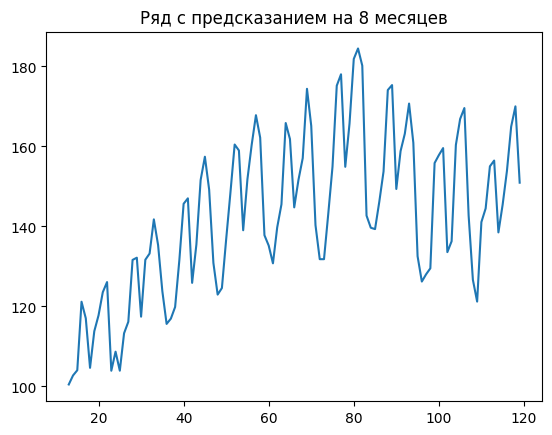

In [157]:
tmp['avg_daily_rate'].plot(title='Ряд с предсказанием на 8 месяцев')

<Axes: title={'center': 'Ряд без предсказания'}>

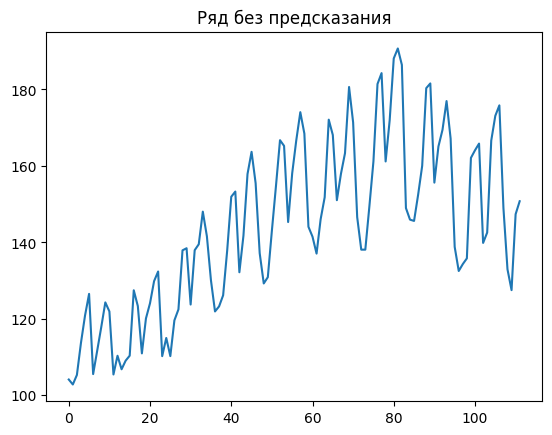

In [158]:
df['avg_daily_rate'].plot(title='Ряд без предсказания')

----

### Метод сезонных индикаций

In [198]:
df_dummies = df[['avg_daily_rate', 'month_n', 'timestamp']]

df_dummies['m1'] = df['month_n'].apply(lambda x: 1 if x == 1 else 0)
df_dummies['m2'] = df['month_n'].apply(lambda x: 1 if x == 2 else 0)
df_dummies['m3'] = df['month_n'].apply(lambda x: 1 if x == 3 else 0)
df_dummies['m4'] = df['month_n'].apply(lambda x: 1 if x == 4 else 0)
df_dummies['m5'] = df['month_n'].apply(lambda x: 1 if x == 5 else 0)
df_dummies['m6'] = df['month_n'].apply(lambda x: 1 if x == 6 else 0)
df_dummies['m7'] = df['month_n'].apply(lambda x: 1 if x == 7 else 0)
df_dummies['m8'] = df['month_n'].apply(lambda x: 1 if x == 8 else 0)
df_dummies['m9'] = df['month_n'].apply(lambda x: 1 if x == 9 else 0)
df_dummies['m10'] = df['month_n'].apply(lambda x: 1 if x == 10 else 0)
df_dummies['m11'] = df['month_n'].apply(lambda x: 1 if x == 11 else 0)
df_dummies['m12'] = df['month_n'].apply(lambda x: 1 if x == 12 else 0)

df_dummies.drop(columns=['month_n'], inplace=True)
df_dummies.dropna(inplace=True)
df_dummies.head(20)

,avg_daily_rate,timestamp,m1,m2,m3,m4,m5,m6,m7,m8,m9,m10,m11,m12
0,104.04,1,1,0,0,0,0,0,0,0,0,0,0,0
1,102.74,2,0,1,0,0,0,0,0,0,0,0,0,0
2,105.23,3,0,0,1,0,0,0,0,0,0,0,0,0
3,113.63,4,0,0,0,1,0,0,0,0,0,0,0,0
4,120.77,5,0,0,0,0,1,0,0,0,0,0,0,0
5,126.46,6,0,0,0,0,0,1,0,0,0,0,0,0
6,105.46,7,0,0,0,0,0,0,1,0,0,0,0,0
7,111.59,8,0,0,0,0,0,0,0,1,0,0,0,0
8,117.78,9,0,0,0,0,0,0,0,0,1,0,0,0
9,124.23,10,0,0,0,0,0,0,0,0,0,1,0,0


In [199]:
X_train = df_dummies[:79].drop(columns='avg_daily_rate')
X_test = df_dummies[79:].drop(columns='avg_daily_rate')

y_train = df_dummies[:79]['avg_daily_rate']
y_test = df_dummies[79:]['avg_daily_rate']

model_dummy = RandomForestRegressor(
    n_estimators=150,
    max_depth=6,
    random_state=10
)

model_dummy.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [200]:
forecast = pd.DataFrame(data={
    'timestamp': [i for i in range(113, 121)],
    'm1': [1 if i % 12 == 1 else 0 for i in range(113, 121)],
    'm2': [1 if i % 12 == 2 else 0 for i in range(113, 121)],
    'm3': [1 if i % 12 == 3 else 0 for i in range(113, 121)],
    'm4': [1 if i % 12 == 4 else 0 for i in range(113, 121)],
    'm5': [1 if i % 12 == 5 else 0 for i in range(113, 121)],
    'm6': [1 if i % 12 == 6 else 0 for i in range(113, 121)],
    'm7': [1 if i % 12 == 7 else 0 for i in range(113, 121)],
    'm8': [1 if i % 12 == 8 else 0 for i in range(113, 121)],
    'm9': [1 if i % 12 == 9 else 0 for i in range(113, 121)],
    'm10': [1 if i % 12 == 10 else 0 for i in range(113, 121)],
    'm11': [1 if i % 12 == 11 else 0 for i in range(113, 121)],
    'm12': [1 if i % 12 == 0 else 0 for i in range(113, 121)]
})

forecast

,timestamp,m1,m2,m3,m4,m5,m6,m7,m8,m9,m10,m11,m12
0,113,0,0,0,0,1,0,0,0,0,0,0,0
1,114,0,0,0,0,0,1,0,0,0,0,0,0
2,115,0,0,0,0,0,0,1,0,0,0,0,0
3,116,0,0,0,0,0,0,0,1,0,0,0,0
4,117,0,0,0,0,0,0,0,0,1,0,0,0
5,118,0,0,0,0,0,0,0,0,0,1,0,0
6,119,0,0,0,0,0,0,0,0,0,0,1,0
7,120,0,0,0,0,0,0,0,0,0,0,0,1


In [201]:
pred = model_dummy.predict(X_test)

print('MAE на тестовой выборке:', round(mean_absolute_error(y_test, pred), 2))

MAE на тестовой выборке: 14.02


In [202]:
pred = model_dummy.predict(forecast)



forecast['avg_daily_rate'] = pred

tmp = pd.concat([
    df_dummies,
    forecast
])

tmp.reset_index(drop=True, inplace=True)

<Axes: title={'center': 'Ряд с предсказанием на 8 месяцев'}>

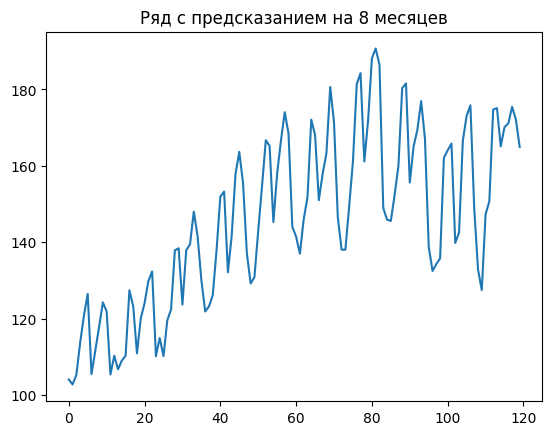

In [203]:
tmp['avg_daily_rate'].plot(title='Ряд с предсказанием на 8 месяцев')

<Axes: title={'center': 'Исходный ряд'}>

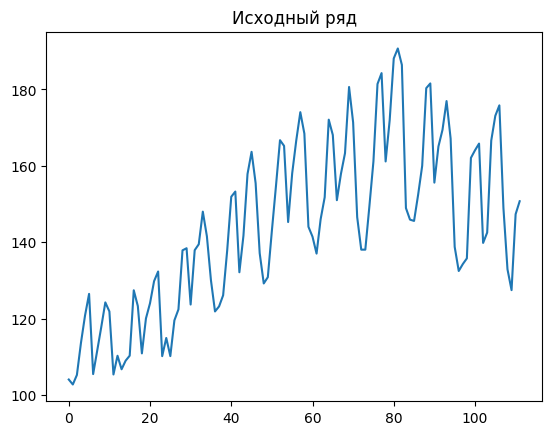

In [204]:
df_dummies['avg_daily_rate'].plot(title='Исходный ряд')